In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [34]:
df = pd.read_csv('/content/dataset.csv')

In [35]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
df.shape

(891, 12)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [38]:
df = df.drop('Cabin',axis = 1)

In [39]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [40]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [41]:
print(df['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [42]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace = True)

In [43]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [44]:
sns.set()

<Axes: xlabel='Sex', ylabel='count'>

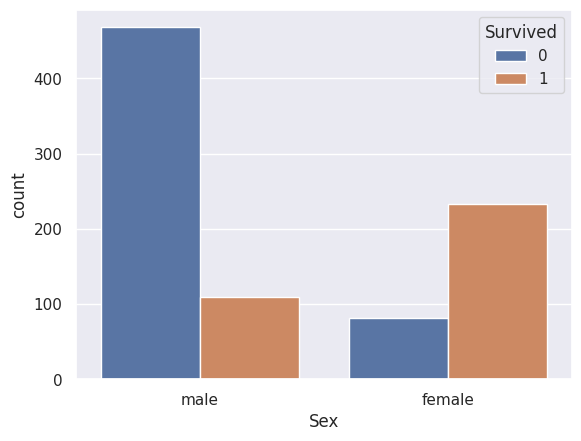

In [47]:
sns.countplot(x='Sex',hue='Survived',data= df)

<Axes: xlabel='Pclass', ylabel='count'>

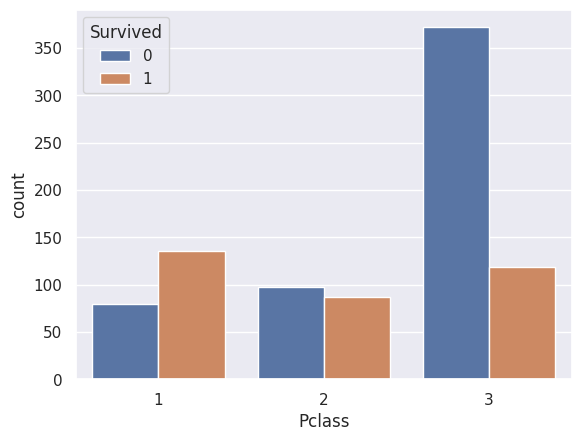

In [48]:
sns.countplot(x='Pclass',hue='Survived',data= df)

In [49]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [51]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [53]:
df.replace({'Sex':{'male' : 0 , 'female' : 1},'Embarked':{'S' : 0 , 'C' : 1 , 'Q' : 2 }},inplace = True)

In [55]:
X = df.drop(columns = ['PassengerId','Name','Ticket','Survived'],axis = 1)
Y = df['Survived']

In [56]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,stratify= Y, test_size=0.2,random_state=2)

In [57]:
model = LogisticRegression()

In [58]:
model.fit(X_train,Y_train)

LogisticRegression()

In [59]:
X_train_prediction = model.predict(X_train)

In [60]:
accuracy_training = metrics.accuracy_score(Y_train,X_train_prediction)
accuracy_training

0.800561797752809

In [61]:
X_test_prediction = model.predict(X_test)

In [63]:
accuracy_testing = metrics.accuracy_score(Y_test,X_test_prediction)
accuracy_testing

0.7932960893854749